# Experiment 3 — Activation noising (mean ablation)

Reproduction guidebook §6.

> **Question.** Are PANL and CC representations **necessary** for confidence reporting?
> **Key result.** Ablating PANL partially disrupts confidence (peak L25–26); CC disrupts from
> L30 onward; PANL+1 does nothing.

**Important conceptual note (§6.2).** Mean ablation does **not** push the model toward a
"neutral" report. The mean of activations encoding high and low confidence is not
an encoding of medium confidence — averaging the embeddings of "brilliant" and "terrible"
does not give "mediocre". Read the result as *disruption*, not as setting confidence to 0.5;
that is why §6.3 reports the **logit-difference change** and the **first-token change rate**
rather than confidence change.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vconf").is_dir())
sys.path.insert(0, str(ROOT))

from vconf import notebook as nb

from vconf import exp2_patching as E2
from vconf import exp3_noising as E3
from vconf import metrics as M
from vconf import plotting
from vconf.results import compare_to_control, peak_layer, summarize

cfg = nb.run_config("gemma-categorical")
print(nb.describe(cfg))
print("primary metrics (§6.3):", E3.PRIMARY_METRICS)

profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
prompt / dataset : categorical / triviaqa
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : True   attention impl: None
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.
primary metrics (§6.3): ('logit_diff_change', 'token_changed')


In [2]:
loaded = nb.open_model(cfg)
trials, rendered = nb.build_trials(loaded, cfg)
trials = nb.graded(trials)
print(len(trials), "trials")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

1000 trials


## The disjoint partition (§2.3.4)

Several sets must be **mutually disjoint**, partitioned once up front: the
**activation-collection set**, the **calibration set** (the means used for patching
corruption and noising), and the per-experiment **test sets**.
`nb.split_activation_holdout` makes the first cut; the balanced calibration set is selected
inside the holdout and the test trials from what is left.

In [3]:
(act_trials, act_rendered), (hold_trials, hold_rendered) = nb.split_activation_holdout(
    trials, rendered, cfg
)
print(f"activation-collection set: {len(act_trials)} trials")
print(f"holdout (calibration + test): {len(hold_trials)} trials")
print("disjoint:", {t.qid for t in act_trials} & {t.qid for t in hold_trials} == set())

activation-collection set: 300 trials
holdout (calibration + test): 700 trials
disjoint: True


## The calibration set (§6.1)

A **balanced** 100-trial set — 50 from the top three classes, 50 from the bottom three —
disjoint from the test set. Its mean residual stream at each (layer, position) is what
replaces the test trial's own activation.

In [4]:
n_cal = cfg.calibration_n // 2
cal_index = E2.select_calibration_trials(hold_trials, n_high=n_cal, n_low=n_cal,
                                         model_key=cfg.model_key)
cal_trials, cal_rendered = nb.subset(hold_trials, hold_rendered, cal_index)
means = E3.mean_activations(loaded, cal_rendered, cfg, positions=("PANL", "PANL+1", "CC"))
print(f"calibration set: {len(cal_trials)} trials")
print("mean activation vectors:", len(means), "(layer, position) pairs")

calibration set: 40 trials
mean activation vectors: 18 (layer, position) pairs


## Test trials (§6.1)

400 trials per layer per position — unlike patching this uses *all* trials, not just
high-confidence ones. (Qwen's protocol splits them 200 high / 100 low, §12.2.)

In [5]:
pool = [i for i in range(len(hold_trials)) if i not in set(cal_index.tolist())]
pool_trials = [hold_trials[i] for i in pool]
split = (2 * cfg.trial_counts["noising"] // 3, cfg.trial_counts["noising"] // 3) \
    if cfg.model_key == "qwen" else None
picked = E3.select_noising_trials(pool_trials, cfg.trial_counts["noising"], split=split,
                                  model_key=cfg.model_key)
index = np.array([pool[i] for i in picked])
test_trials, test_rendered = nb.subset(hold_trials, hold_rendered, index)
print(f"{len(test_trials)} test trials; disjoint from calibration:",
      set(index.tolist()) & set(cal_index.tolist()) == set())

31 test trials; disjoint from calibration: True


In [6]:
frame = E3.run_noising(loaded, test_rendered, test_trials, means, cfg,
                       positions=("PANL", "PANL+1", "CC"))
summary = summarize(frame, by=("position", "layer"))
summary

,position,layer,n,confidence_change_mean,confidence_change_sem,logit_diff_change_mean,logit_diff_change_sem,token_changed_mean,token_changed_sem
0,CC,0,31,0.006452,0.006452,-0.010081,0.012228,0.032258,0.032258
1,CC,5,31,0.006452,0.006452,0.002016,0.013728,0.032258,0.032258
2,CC,11,31,0.006452,0.006452,-0.010305,0.013765,0.032258,0.032258
3,CC,16,31,0.012903,0.008971,-0.028002,0.016184,0.064516,0.044853
4,CC,22,31,0.096774,0.025604,-3.514337,0.209155,0.322581,0.085347
5,CC,27,31,0.096774,0.025604,-3.401658,0.244185,0.322581,0.085347
6,PANL,0,31,0.000000,0.000000,0.060036,0.049457,0.000000,0.000000
7,PANL,5,31,0.009677,0.009677,-0.038978,0.139679,0.032258,0.032258
8,PANL,11,31,-0.012903,0.015199,-0.409050,0.234174,0.096774,0.053978
9,PANL,16,31,0.045161,0.019030,-0.202061,0.265147,0.161290,0.067151


## Disruption against layer (§6.4)

**Directional prediction.** If a position is necessary, ablating it should **reduce the logit
difference** and **increase the first-token change rate**.

clean logit difference: 7.00  (paper: 9.4)


PosixPath('/scratch/qi/project/results/figures/exp3-noising-qwen-categorical-triviaqa-reduced.png')

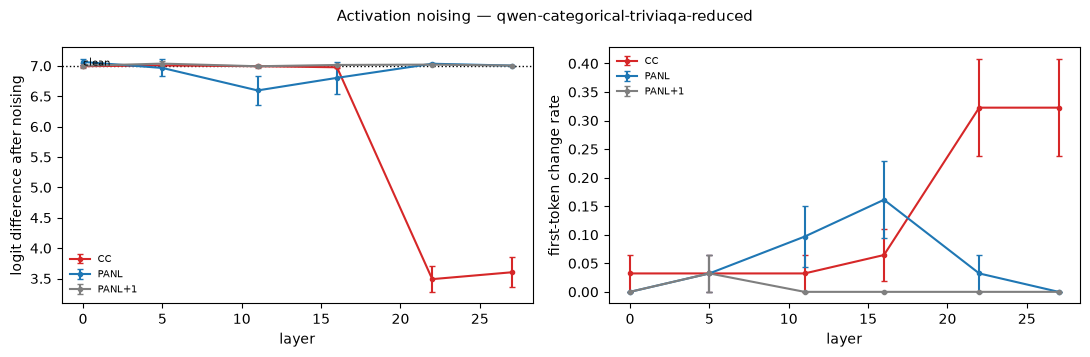

In [7]:
clean_logit_diff = float(frame.groupby("position")["clean_logit_diff"].mean().mean())
print(f"clean logit difference: {clean_logit_diff:.2f}  (paper: {E3.PAPER_TARGETS['clean_logit_diff']})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for position, group in summary.groupby("position"):
    group = group.sort_values("layer")
    axes[0].errorbar(group["layer"], clean_logit_diff + group["logit_diff_change_mean"],
                     yerr=group["logit_diff_change_sem"], marker="o", markersize=3, capsize=2,
                     color=plotting.POSITION_COLORS.get(position), label=position)
    axes[1].errorbar(group["layer"], group["token_changed_mean"],
                     yerr=group["token_changed_sem"], marker="o", markersize=3, capsize=2,
                     color=plotting.POSITION_COLORS.get(position), label=position)
axes[0].axhline(clean_logit_diff, color="k", ls=":", lw=1)
axes[0].annotate("clean", (cfg.layers[0], clean_logit_diff), fontsize=7)
axes[0].set_ylabel("logit difference after noising")
axes[1].set_ylabel("first-token change rate")
for ax in axes:
    ax.set_xlabel("layer")
    ax.legend(fontsize=7, frameon=False)
fig.suptitle(f"Activation noising — {cfg.name}", fontsize=11)
fig.tight_layout()
plotting.save_figure(fig, f"exp3-noising-{cfg.name}")

## Peak layers (§6.4)

| Position | Logit diff after noising | First-token change rate | Peak layer |
|---|---|---|---|
| **PANL** | ≈ 8.4 (≈ 11% reduction from 9.4) | peaks ≈ 14% | **L25–26** |
| **CC** | falls to ≈ 2.8 by L61 | rises to ≈ 78% | rises after L30 |
| **PANL+1** | flat at clean (≈ 9.4) | flat ≈ 3–4% | none |

In [8]:
peaks = {p: peak_layer(summary, "token_changed", p, mode="max")
         for p in ("PANL", "PANL+1", "CC")}
paper_peaks = E3.PEAK_LAYERS.get(
    "gemma-categorical" if cfg.model_key == "gemma" else "qwen-categorical", {}
)
rows = []
for position in ("PANL", "PANL+1", "CC"):
    group = summary[summary["position"] == position]
    rows.append({
        "position": position,
        "peak layer": peaks[position],
        "paper peak layer": paper_peaks.get(position),
        "max first-token change rate": round(float(group["token_changed_mean"].max()), 4),
        "paper": E3.PAPER_TARGETS[position]["token_change_rate"],
        "min logit difference": round(float(
            clean_logit_diff + group["logit_diff_change_mean"].min()), 3),
        "paper logit diff": E3.PAPER_TARGETS[position]["logit_diff"],
    })
pd.DataFrame(rows)

,position,peak layer,paper peak layer,max first-token change rate,paper,min logit difference,paper logit diff
0,PANL,16,11,0.1613,0.140,6.595,8.4
1,PANL+1,5,6,0.0323,0.035,6.993,9.4
2,CC,22,21,0.3226,0.780,3.490,2.8


In [9]:
for position in ("PANL", "CC"):
    stats = compare_to_control(frame, "token_changed", position, control="PANL+1",
                               layer=peaks[position])
    print(f"{position} vs PANL+1 at L{peaks[position]}: "
          f"Δ change rate = {stats['mean_difference']:+.3f} ± {stats['sem_difference']:.3f}, "
          f"p = {stats['t_p']:.3g}")

PANL vs PANL+1 at L16: Δ change rate = +0.161 ± 0.067, p = 0.0227
CC vs PANL+1 at L22: Δ change rate = +0.323 ± 0.085, p = 0.000697


In [10]:
panl = summary[summary["position"] == "PANL"]
control = summary[summary["position"] == "PANL+1"]
checks = {
    "Q5 noising PANL disrupts confidence": float(panl["token_changed_mean"].max())
        > float(control["token_changed_mean"].max()),
    "Q5 PANL+1 does not": float(control["token_changed_mean"].max())
        < float(panl["token_changed_mean"].max()),
    "ablation reduces the logit difference at PANL": float(panl["logit_diff_change_mean"].min()) < 0,
    "Q3 PANL peaks before CC": peaks["PANL"] <= peaks["CC"],
    "disruption is partial, not total": float(panl["token_changed_mean"].max()) < 1.0,
}
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")

PASS  Q5 noising PANL disrupts confidence
PASS  Q5 PANL+1 does not
PASS  ablation reduces the logit difference at PANL
PASS  Q3 PANL peaks before CC
PASS  disruption is partial, not total


**Interpretation.** PANL and CC ablation cause **partial** disruption; PANL+1 causes
none. Partial rather than complete disruption is expected, reflecting either confidence
encoding distributed across layers or functional redundancy. The CC effect at very late
layers is again partly trivial — CC feeds the unembedding directly — so the diagnostic
content is the PANL effect and its **earlier** peak.